Confidence Interval (90%): (5.631214861236672, 6.160990949310203)


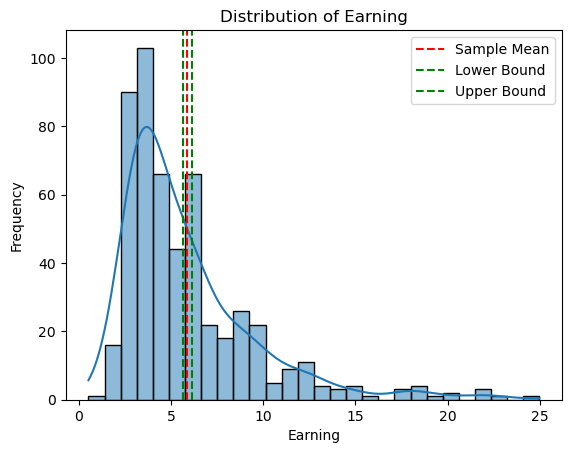

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stata file
data = pd.read_stata("WAGE1.dta")

# Extract the "earning" column
earning = data["earning"]

# Calculate the sample mean and standard deviation
sample_mean = np.mean(earning)
sample_std = np.std(earning, ddof=1)  # Set ddof=1 for sample standard deviation

# Calculate the standard error
n = len(earning)
standard_error = sample_std / np.sqrt(n)

# Calculate the margin of error
z_critical = 1.645  # 90% confidence level (z-score for 90% confidence interval)
margin_of_error = z_critical * standard_error

# Calculate the confidence interval
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

# Print the confidence interval
print("Confidence Interval (90%):", confidence_interval)

# Plotting the bell-shaped curve
sns.histplot(earning, kde=True)
plt.axvline(sample_mean, color='red', linestyle='--', label='Sample Mean')
plt.axvline(confidence_interval[0], color='green', linestyle='--', label='Lower Bound')
plt.axvline(confidence_interval[1], color='green', linestyle='--', label='Upper Bound')
plt.legend()
plt.xlabel('Earning')
plt.ylabel('Frequency')
plt.title('Distribution of Earning')
plt.show()


Correlation Coefficient: 0.11290343806353428


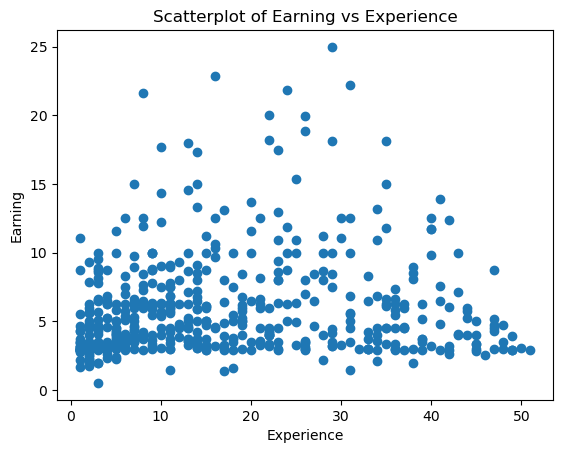

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Stata file
data = pd.read_stata("WAGE1.dta")

# Extract the "earning" and "exp" columns
earning = data["earning"]
experience = data["exp"]

# Create a scatterplot
plt.scatter(experience, earning)
plt.xlabel("Experience")
plt.ylabel("Earning")
plt.title("Scatterplot of Earning vs Experience")

# Compute the correlation coefficient
correlation_coefficient = earning.corr(experience)

# Print the correlation coefficient
print("Correlation Coefficient:", correlation_coefficient)

# Show the plot
plt.show()


In [3]:
import pandas as pd
import statsmodels.api as sm

# Load the Stata file
data = pd.read_stata("WAGE1.dta")

# Extract the "earning" and "edu" columns
earning = data["earning"]
education_years = data["edu"]

# Add a constant column to the independent variable
education_years = sm.add_constant(education_years)

# Fit the OLS model
model = sm.OLS(earning, education_years)
results = model.fit()

# Print the regression summary
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                earning   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Tue, 06 Jun 2023   Prob (F-statistic):           2.78e-22
Time:                        02:46:59   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9049      0.685     -1.321      0.1

In [4]:
import pandas as pd
import statsmodels.api as sm

# Assuming you have the dataset with "edu" and "earning" variables loaded as `data`

# Add constant term to the data
data_with_const = sm.add_constant(data)

# Fit the OLS regression model
model = sm.OLS(data_with_const['earning'], data_with_const[['const', 'edu']])
results = model.fit()

# Extract the p-value associated with the coefficient of "edu"
p_value = results.pvalues['edu']

# Check if the effect of "edu" is statistically significant at a significance level of 0.05 (commonly used threshold)
if p_value < 0.05:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

# Print the results
print(f"The effect of 'edu' on 'earning' is {significance}.")
print(f"Null hypothesis: The coefficient of 'edu' is equal to zero.")
print(f"Alternative hypothesis: The coefficient of 'edu' is not equal to zero.")


The effect of 'edu' on 'earning' is statistically significant.
Null hypothesis: The coefficient of 'edu' is equal to zero.
Alternative hypothesis: The coefficient of 'edu' is not equal to zero.


In [5]:
import pandas as pd
import statsmodels.api as sm

# Assuming you have the dataset with "edu" and "earning" variables loaded as `data`

# Add constant term to the data
data_with_const = sm.add_constant(data)

# Fit the OLS regression model
model = sm.OLS(data_with_const['earning'], data_with_const[['const', 'edu']])
results = model.fit()

# Construct the confidence interval
ci = results.conf_int(alpha=0.05)  # 95% confidence interval

# Extract the lower and upper bounds of the confidence interval
lower_bound = ci.loc['edu'][0]
upper_bound = ci.loc['edu'][1]

# Print the confidence interval
print(f"The 95% confidence interval for the effect of 'edu' on 'earning' is: [{lower_bound}, {upper_bound}]")


The 95% confidence interval for the effect of 'edu' on 'earning' is: [0.4367534056238659, 0.6459651037064836]


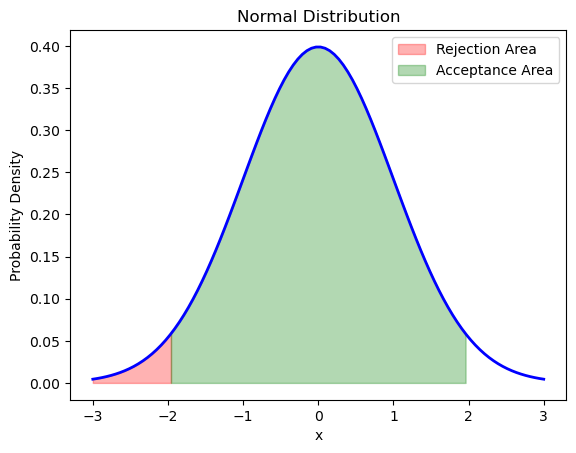

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data for the normal distribution
mu = 0  # mean
sigma = 1  # standard deviation
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)  # x-values for the curve
y = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)  # y-values for the curve

# Create the plot
fig, ax = plt.subplots()

# Plot the bell-shaped curve
ax.plot(x, y, 'b-', linewidth=2)

# Shade the rejection and acceptance areas
x_reject = np.linspace(mu - 3*sigma, -1.96*sigma, 100)
y_reject = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_reject - mu)/sigma)**2)
ax.fill_between(x_reject, y_reject, color='red', alpha=0.3, label='Rejection Area')

x_accept = np.linspace(-1.96*sigma, 1.96*sigma, 100)
y_accept = (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_accept - mu)/sigma)**2)
ax.fill_between(x_accept, y_accept, color='green', alpha=0.3, label='Acceptance Area')

# Set labels and title
ax.set_xlabel('x')
ax.set_ylabel('Probability Density')
ax.set_title('Normal Distribution')

# Add a legend
ax.legend()

# Show the plot
plt.show()


In [7]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
data = pd.read_stata('WAGE1.dta')

# Define the dependent variable
y = data['earning']

# Define the independent variables
X = data[['exp', 'edu', 'tenure', 'female']]

# Add a constant column to the independent variables
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X)
results = model.fit()

# Print the regression results
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                earning   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     74.40
Date:                Tue, 06 Jun 2023   Prob (F-statistic):           7.30e-50
Time:                        02:59:55   Log-Likelihood:                -1314.2
No. Observations:                 526   AIC:                             2638.
Df Residuals:                     521   BIC:                             2660.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5679      0.725     -2.164      0.0

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load the Stata file into a pandas DataFrame
data = pd.read_stata('WAGE1.dta')

data



,earning,edu,exp,tenure,nonwhite,female
0,3.10,11,2,0,0,1
1,3.24,12,22,2,0,1
2,3.00,11,2,0,0,0
3,6.00,8,44,28,0,0
4,5.30,12,7,2,0,0
...,...,...,...,...,...,...
521,15.00,16,14,2,0,1
522,2.27,10,2,0,0,1
523,4.67,15,13,18,0,0
524,11.56,16,5,1,0,0


In [15]:
import pandas as pd
import statsmodels.api as sm

# Load the data
data = pd.read_stata('WAGE1.DTA')

# Model 1: All variables
model1 = sm.OLS(data['earning'], sm.add_constant(data[['edu', 'exp', 'tenure', 'female']]))
results1 = model1.fit()

# Model 2: Excluding 'exp'
model2 = sm.OLS(data['earning'], sm.add_constant(data[['edu', 'tenure', 'female']]))
results2 = model2.fit()

# Model 3: Excluding 'tenure'
model3 = sm.OLS(data['earning'], sm.add_constant(data[['edu', 'exp', 'female']]))
results3 = model3.fit()

# Model 4: Excluding 'female'
model4 = sm.OLS(data['earning'], sm.add_constant(data[['edu', 'exp', 'tenure']]))
results4 = model4.fit()

# Omitted variable tests
ov_test_exp = results1.f_test('(exp = 0)')
ov_test_tenure = results1.f_test('(tenure = 0)')
ov_test_female = results1.f_test('(female = 0)')

# Print results
print("Model 1: All variables")
print(results1.summary())
print("Model 2: Excluding 'exp'")
print(results2.summary())
print("Model 3: Excluding 'tenure'")
print(results3.summary())
print("Model 4: Excluding 'female'")
print(results4.summary())
print("p-value for 'exp':", ov_test_exp.pvalue)
print("p-value for 'tenure':", ov_test_tenure.pvalue)
print("p-value for 'female':", ov_test_female.pvalue)


Model 1: All variables
                            OLS Regression Results                            
Dep. Variable:                earning   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     74.40
Date:                Tue, 06 Jun 2023   Prob (F-statistic):           7.30e-50
Time:                        03:31:37   Log-Likelihood:                -1314.2
No. Observations:                 526   AIC:                             2638.
Df Residuals:                     521   BIC:                             2660.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5679      0.

In [16]:
import statsmodels.api as sm
import pandas as pd

# Load your dataset and assign it to a DataFrame, assuming your dataset has variables "earning", "exp", "edu", "tenure", "female", and "nonwhite"
df = pd.read_stata('WAGE1.dta')

# Model 1: Regression with "exp", "edu", "tenure", "female", and "nonwhite" as predictors
model1 = sm.OLS(df['earning'], sm.add_constant(df[['exp', 'edu', 'tenure', 'female', 'nonwhite']])).fit()

# Model 2: Regression with only "exp", "edu", "tenure", and "female" as predictors (without "nonwhite")
model2 = sm.OLS(df['earning'], sm.add_constant(df[['exp', 'edu', 'tenure', 'female']])).fit()

# Print the summary statistics for Model 1 and Model 2
print("Model 1 with 'nonwhite' as a control variable:")
print(model1.summary())
print("\nModel 2 without 'nonwhite' as a control variable:")
print(model2.summary())

# Compare the adjusted R-squared values for Model 1 and Model 2
adj_r2_model1 = model1.rsquared_adj
adj_r2_model2 = model2.rsquared_adj

print("\nAdjusted R-squared for Model 1:", adj_r2_model1)
print("Adjusted R-squared for Model 2:", adj_r2_model2)


Model 1 with 'nonwhite' as a control variable:
                            OLS Regression Results                            
Dep. Variable:                earning   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     59.43
Date:                Tue, 06 Jun 2023   Prob (F-statistic):           6.48e-49
Time:                        03:48:39   Log-Likelihood:                -1314.2
No. Observations:                 526   AIC:                             2640.
Df Residuals:                     520   BIC:                             2666.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

In [17]:
import statsmodels.api as sm
import pandas as pd

# Load the data into a DataFrame
data = pd.read_stata("WAGE1.dta")

# Create the interaction term between education and race
data["edu_nonwhite"] = data["edu"] * data["nonwhite"]

# Define the independent variables and the dependent variable
X = data[["exp", "edu", "tenure", "female", "nonwhite", "edu_nonwhite"]]
y = data["earning"]

# Add a constant to the independent variables
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X)
results = model.fit()

# Print the regression results
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                earning   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     49.44
Date:                Tue, 06 Jun 2023   Prob (F-statistic):           5.18e-48
Time:                        03:53:36   Log-Likelihood:                -1314.2
No. Observations:                 526   AIC:                             2642.
Df Residuals:                     519   BIC:                             2672.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.5860      0.771     -2.057   

In [18]:
import statsmodels.api as sm
import pandas as pd

# Load the data into a DataFrame
data = pd.read_stata("WAGE1.dta")

# Create the squared term of experience
data["expersq"] = data["exp"] ** 2

# Define the independent variables and the dependent variable
X = data[["exp", "expersq", "edu", "tenure", "female"]]
y = data["earning"]

# Add a constant to the independent variables
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X)
results = model.fit()

# Print the regression results
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                earning   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     59.51
Date:                Tue, 06 Jun 2023   Prob (F-statistic):           5.66e-49
Time:                        03:56:03   Log-Likelihood:                -1314.1
No. Observations:                 526   AIC:                             2640.
Df Residuals:                     520   BIC:                             2666.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5918      0.726     -2.192      0.0